# Results Aggregation — cka_vs_baselines

Collects all `partial_result_{n}_{seed}.csv` files, averages over seeds,
computes standard errors (SE = std / sqrt(num_seeds)), and produces a LaTeX table.

Varies n in [2000, 2500, 3000]. Compares:
- **AMP:** DAIF-CKA (clustered with CKA, 2 clusters)
- **Baselines:** AJIVE, MCCA, GCCA, MFA, HPCA

**Table format:** `mean(se)` — e.g. `0.047(0.003)`. Bold = best mean per column.

In [1]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Latex

# ---------------------------------------------------------------
# Configuration
# ---------------------------------------------------------------
RESULTS_DIR    = "../Results/cka_vs_baselines"
os.makedirs(RESULTS_DIR, exist_ok=True)
PLOTS_DIR      = "../Plots"
os.makedirs(PLOTS_DIR, exist_ok=True)
OUTPUT_CSV     = "output_cka_vs_baselines.csv"
OUTPUT_TEX     = "results_table_cka_vs_baselines.tex"

N_VALUES       = [2000, 2500, 3000]
NUM_MODALITIES = 3
NUM_TRIALS     = 25    # expected seeds per n

# Internal method names -> display names (order = table column order)
METHOD_LABELS = {
    "amp_clustered_cka": "DAIF-CKA",
    "ajive": "AJIVE",
    "mcca":  "MCCA",
    "gcca":  "GCCA",
    "hpca":  "HPCA",
}

AMP_METHODS      = ["amp_clustered_cka"]
BASELINE_METHODS = ["ajive", "mcca", "gcca", "hpca"]

In [2]:
# ---------------------------------------------------------------
# Load all partial results
# ---------------------------------------------------------------
pattern = os.path.join(RESULTS_DIR, "partial_result_*.csv")
files   = glob.glob(pattern)

if not files:
    raise FileNotFoundError(f"No partial result files found in {RESULTS_DIR}")

print(f"Found {len(files)} partial result files.")
df_all = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)
print(f"Total rows: {len(df_all)}")
df_all.head()

Found 75 partial result files.
Total rows: 375


,n,seed,method,modality_1,modality_2,modality_3
0,2500,0,amp_clustered_cka,0.015790,0.016865,0.012375
1,2500,0,ajive,0.183330,2.110268,2.001271
2,2500,0,mcca,0.377636,0.143996,0.041651
3,2500,0,gcca,0.372652,0.143245,0.041658
4,2500,0,hpca,0.373216,0.146153,0.042336


In [3]:
# ---------------------------------------------------------------
# Check completeness — warn about missing (n, seed) combinations
# ---------------------------------------------------------------
print("Completeness check:")
for n in N_VALUES:
    df_n    = df_all[(df_all["n"] == n) & (df_all["method"] == "amp_clustered_cka")]
    n_seeds = df_n["seed"].nunique()
    status  = "OK" if n_seeds >= NUM_TRIALS else f"WARNING: only {n_seeds}/{NUM_TRIALS} seeds"
    print(f"  n={n}: {n_seeds} seeds — {status}")

Completeness check:
  n=2000: 25 seeds — OK
  n=2500: 25 seeds — OK
  n=3000: 25 seeds — OK


In [4]:
# ---------------------------------------------------------------
# Aggregate: mean and SE per (n, method, modality)
# summary[method][n] = {'mean': [m1,m2,m3], 'se': [se1,se2,se3]}
# ---------------------------------------------------------------
summary = {method: {} for method in METHOD_LABELS}

for method in METHOD_LABELS:
    for n in N_VALUES:
        df_s     = df_all[(df_all["method"] == method) & (df_all["n"] == n)]
        n_trials = len(df_s)
        if n_trials == 0:
            summary[method][n] = {"mean": [np.nan]*NUM_MODALITIES, "se": [np.nan]*NUM_MODALITIES}
            continue
        means = [df_s[f"modality_{i+1}"].mean() for i in range(NUM_MODALITIES)]
        ses   = [df_s[f"modality_{i+1}"].std() / np.sqrt(n_trials) for i in range(NUM_MODALITIES)]
        summary[method][n] = {"mean": means, "se": ses}

# Sanity print
for method, label in METHOD_LABELS.items():
    print(f"{label}:")
    for n in N_VALUES:
        vals = summary[method][n]
        print(f"  n={n}: mean={[round(v,4) for v in vals['mean']]}  se={[round(v,4) for v in vals['se']]}")

DAIF-CKA:
  n=2000: mean=[np.float64(0.0129), np.float64(0.0161), np.float64(0.0056)]  se=[np.float64(0.0007), np.float64(0.0006), np.float64(0.0003)]
  n=2500: mean=[np.float64(0.0132), np.float64(0.0153), np.float64(0.0057)]  se=[np.float64(0.0006), np.float64(0.0005), np.float64(0.0004)]
  n=3000: mean=[np.float64(0.012), np.float64(0.0147), np.float64(0.0052)]  se=[np.float64(0.0006), np.float64(0.0004), np.float64(0.0002)]
AJIVE:
  n=2000: mean=[np.float64(0.1833), np.float64(2.1186), np.float64(2.0029)]  se=[np.float64(0.0009), np.float64(0.0014), np.float64(0.0007)]
  n=2500: mean=[np.float64(0.1839), np.float64(2.1166), np.float64(2.0027)]  se=[np.float64(0.0009), np.float64(0.0011), np.float64(0.0009)]
  n=3000: mean=[np.float64(0.1825), np.float64(2.1161), np.float64(2.0031)]  se=[np.float64(0.0009), np.float64(0.001), np.float64(0.0009)]
MCCA:
  n=2000: mean=[np.float64(0.3709), np.float64(0.1404), np.float64(0.0351)]  se=[np.float64(0.0019), np.float64(0.0009), np.float64(0

In [5]:
# ---------------------------------------------------------------
# Save flat summary CSV
# ---------------------------------------------------------------
rows = []
for method, label in METHOD_LABELS.items():
    for n in N_VALUES:
        vals = summary[method][n]
        row  = {"method": label, "n": n}
        for i in range(NUM_MODALITIES):
            row[f"modality_{i+1}_mean"] = vals["mean"][i]
            row[f"modality_{i+1}_se"]   = vals["se"][i]
        rows.append(row)

df_summary = pd.DataFrame(rows)
df_summary.to_csv(OUTPUT_CSV, index=False)
print(f"Saved {OUTPUT_CSV}")
df_summary

Saved output_cka_vs_baselines.csv


,method,n,modality_1_mean,modality_1_se,modality_2_mean,modality_2_se,modality_3_mean,modality_3_se
0,DAIF-CKA,2000,0.012863,0.000681,0.016083,0.000555,0.005613,0.000270
1,DAIF-CKA,2500,0.013180,0.000560,0.015255,0.000454,0.005669,0.000370
2,DAIF-CKA,3000,0.012046,0.000588,0.014698,0.000352,0.005180,0.000175
3,AJIVE,2000,0.183272,0.000910,2.118585,0.001420,2.002895,0.000702
4,AJIVE,2500,0.183916,0.000859,2.116638,0.001088,2.002735,0.000908
5,AJIVE,3000,0.182458,0.000874,2.116079,0.000995,2.003145,0.000946
6,MCCA,2000,0.370886,0.001859,0.140395,0.000927,0.035069,0.000398
7,MCCA,2500,0.374427,0.001244,0.139132,0.000781,0.035038,0.000399
8,MCCA,3000,0.371134,0.001562,0.137400,0.000581,0.034859,0.000328
9,GCCA,2000,0.365794,0.001763,0.139681,0.000921,0.035323,0.000515


In [6]:
# ---------------------------------------------------------------
# Build LaTeX table
#
# Structure:
#   Columns: Modality, n, DAIF-CKA, AJIVE, MCCA, GCCA, HPCA
#   Rows: grouped by modality (multirow), n values within each block
#   Format: mean(se), bold = best (lowest error) per row
# ---------------------------------------------------------------

def build_latex_table(summary, n_values, method_labels, num_modalities):
    all_methods = list(method_labels.keys())
    col_headers = ' & '.join([f'\\textbf{{{label}}}' for label in method_labels.values()])

    lines = []
    lines.append(r'\begin{table}[htbp]')
    lines.append(r'\scriptsize')
    lines.append(r'\centering')
    lines.append(r'\begin{tabular}{llrrrrr}')
    lines.append(r'\toprule')
    lines.append(f'Modality & $n$ & {col_headers} \\\\')
    lines.append(r'\midrule')

    for mod_idx in range(num_modalities):
        mod_label = r'$\mathcal{E}_' + str(mod_idx + 1) + r'$'

        for i, n in enumerate(n_values):
            # Row minimum for bolding (lower error = better)
            row_vals = [
                summary[m][n]['mean'][mod_idx]
                for m in all_methods
                if not np.isnan(summary[m][n]['mean'][mod_idx])
            ]
            row_min = min(row_vals) if row_vals else np.nan

            cells = []
            for method in all_methods:
                mean = summary[method][n]['mean'][mod_idx]
                se   = summary[method][n]['se'][mod_idx]
                if np.isnan(mean):
                    cells.append('---')
                    continue
                cell = f'{mean:.3f}({se:.3f})'
                if abs(mean - row_min) < 1e-9:
                    cell = r'\textbf{' + cell + '}'
                cells.append(cell)

            # First row of block gets the multirow modality label
            if i == 0:
                mod_col = (r'\multirow{' + str(len(n_values)) + r'}{*}{'
                           + mod_label + r'}')
            else:
                mod_col = ''

            lines.append(f'{mod_col} & {n} & ' + ' & '.join(cells) + r' \\')

        if mod_idx < num_modalities - 1:
            lines.append(r'\midrule')

    lines.append(r'\bottomrule')
    lines.append(r'\end{tabular}')
    lines.append(
        r'\caption{Average reconstruction error $\mathcal{E}_k$ per modality '
        r'across sample sizes (mean with standard error in parentheses). '
        r'\textbf{DAIF-CKA}: AMP with CKA-based clustering (2 clusters). '
        r'Bold = best mean per row.}'
    )
    lines.append(r'\label{tab:cka_vs_baselines}')
    lines.append(r'\end{table}')

    return '\n'.join(lines)


latex_str = build_latex_table(summary, N_VALUES, METHOD_LABELS, NUM_MODALITIES)
print(latex_str)

\begin{table}[htbp]
\scriptsize
\centering
\begin{tabular}{llrrrrr}
\toprule
Modality & $n$ & \textbf{DAIF-CKA} & \textbf{AJIVE} & \textbf{MCCA} & \textbf{GCCA} & \textbf{HPCA} \\
\midrule
\multirow{3}{*}{$\mathcal{E}_1$} & 2000 & \textbf{0.013(0.001)} & 0.183(0.001) & 0.371(0.002) & 0.366(0.002) & 0.367(0.002) \\
 & 2500 & \textbf{0.013(0.001)} & 0.184(0.001) & 0.374(0.001) & 0.369(0.001) & 0.370(0.001) \\
 & 3000 & \textbf{0.012(0.001)} & 0.182(0.001) & 0.371(0.002) & 0.366(0.002) & 0.366(0.002) \\
\midrule
\multirow{3}{*}{$\mathcal{E}_2$} & 2000 & \textbf{0.016(0.001)} & 2.119(0.001) & 0.140(0.001) & 0.140(0.001) & 0.144(0.001) \\
 & 2500 & \textbf{0.015(0.000)} & 2.117(0.001) & 0.139(0.001) & 0.139(0.001) & 0.142(0.001) \\
 & 3000 & \textbf{0.015(0.000)} & 2.116(0.001) & 0.137(0.001) & 0.137(0.001) & 0.139(0.001) \\
\midrule
\multirow{3}{*}{$\mathcal{E}_3$} & 2000 & \textbf{0.006(0.000)} & 2.003(0.001) & 0.035(0.000) & 0.035(0.001) & 0.036(0.000) \\
 & 2500 & \textbf{0.006(0.000)} 

In [7]:
# ---------------------------------------------------------------
# Render LaTeX table inline
# ---------------------------------------------------------------
display(Latex(latex_str))

<IPython.core.display.Latex object>

In [8]:
# ---------------------------------------------------------------
# Save .tex file
# ---------------------------------------------------------------
with open(OUTPUT_TEX, "w") as f:
    f.write(latex_str)
print(f"Saved {OUTPUT_TEX}")

Saved results_table_cka_vs_baselines.tex


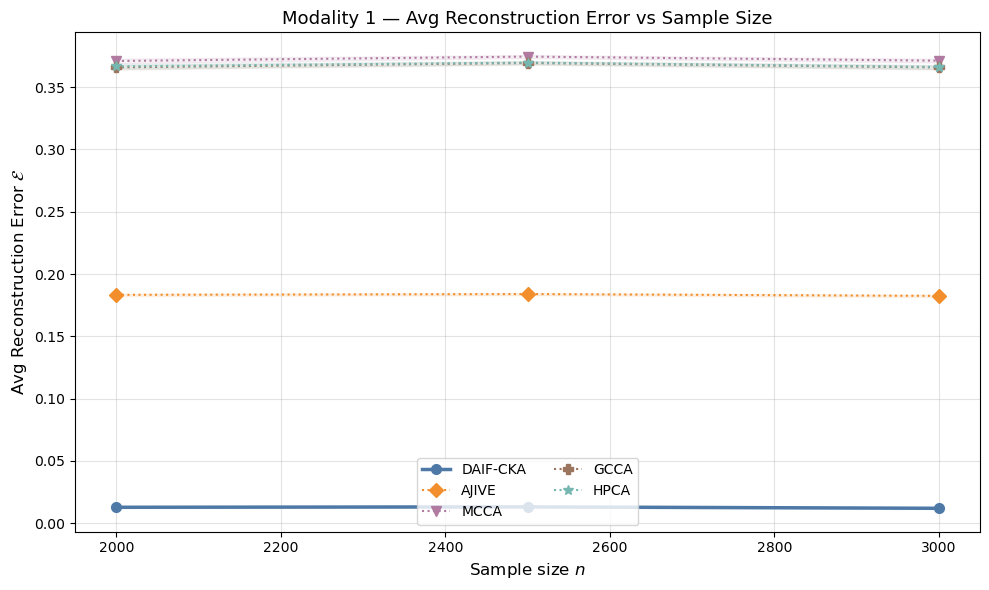

Saved ../Plots/cka_vs_baselines_modality_1_rec_error_vs_n.png


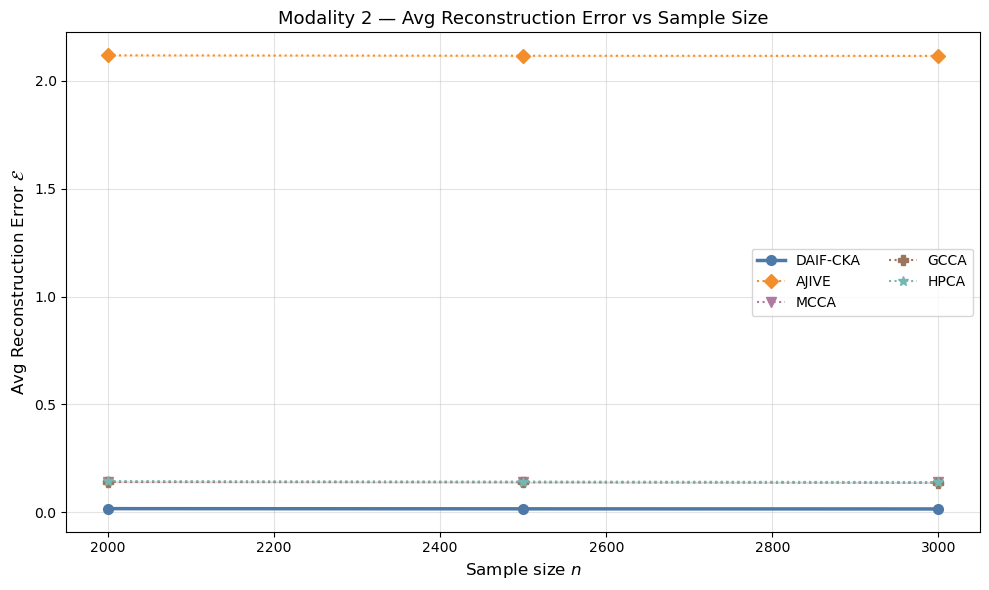

Saved ../Plots/cka_vs_baselines_modality_2_rec_error_vs_n.png


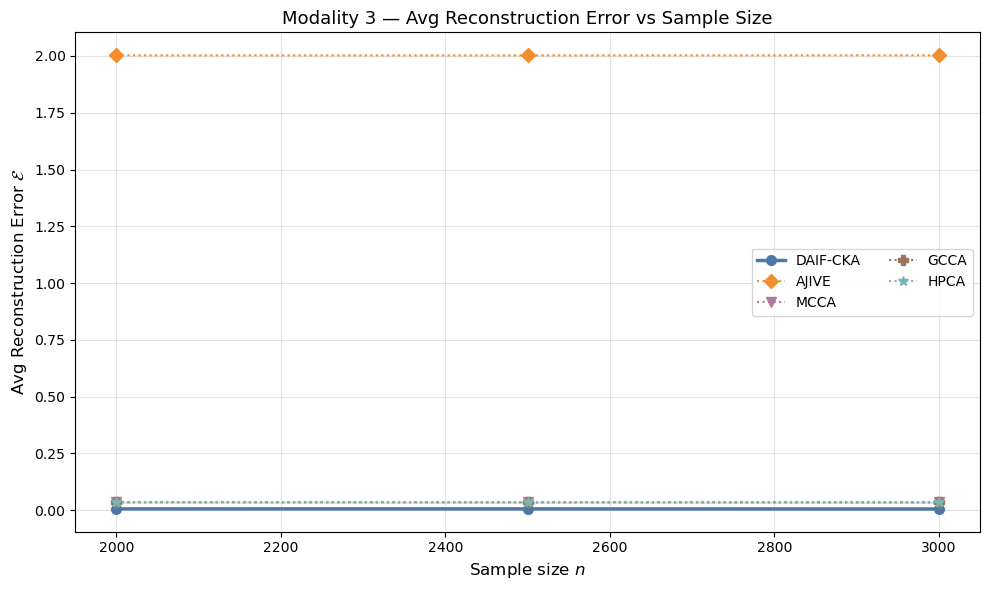

Saved ../Plots/cka_vs_baselines_modality_3_rec_error_vs_n.png


In [9]:
# ---------------------------------------------------------------
# Line plots — mean with SE band vs n, one plot per modality
# ---------------------------------------------------------------
METHOD_STYLES = {
    "amp_clustered_cka": {"marker": "o", "linestyle": "-",  "color": "#4E79A7", "lw": 2.5},
    "ajive": {"marker": "D", "linestyle": ":", "color": "#F28E2B", "lw": 1.5},
    "mcca":  {"marker": "v", "linestyle": ":", "color": "#B07AA1", "lw": 1.5},
    "gcca":  {"marker": "P", "linestyle": ":", "color": "#9C755F", "lw": 1.5},
    "hpca":  {"marker": "*", "linestyle": ":", "color": "#76B7B2", "lw": 1.5},
}

for mod_idx in range(NUM_MODALITIES):
    fig, ax = plt.subplots(figsize=(10, 6))

    for method, label in METHOD_LABELS.items():
        means = np.array([summary[method][n]['mean'][mod_idx] for n in N_VALUES])
        ses   = np.array([summary[method][n]['se'][mod_idx]   for n in N_VALUES])
        style = METHOD_STYLES[method]

        ax.plot(
            N_VALUES, means,
            label=label,
            marker=style['marker'], linestyle=style['linestyle'],
            color=style['color'], linewidth=style['lw'], markersize=7
        )
        ax.fill_between(
            N_VALUES,
            means - ses, means + ses,
            color=style['color'], alpha=0.1
        )

    ax.set_title(
        f'Modality {mod_idx + 1} — Avg Reconstruction Error vs Sample Size',
        fontsize=13
    )
    ax.set_xlabel('Sample size $n$', fontsize=12)
    ax.set_ylabel(r'Avg Reconstruction Error $\mathcal{E}$', fontsize=12)
    ax.grid(True, alpha=0.35)
    ax.legend(fontsize=10, ncol=2)
    fig.tight_layout()

    path = os.path.join(PLOTS_DIR, f'cka_vs_baselines_modality_{mod_idx+1}_rec_error_vs_n.png')
    fig.savefig(path, dpi=150)
    plt.show()
    print(f'Saved {path}')